<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item">
<li><span><a href="#1-数据导入及预处理" data-toc-modified-id="1-数据导入及预处理-1">1 数据导入及预处理</a></span>
    <ul class="toc-item">
    <li><span><a href="#1.1-数据导入" data-toc-modified-id="1.1-数据导入-1.1">1.1 数据导入</a></span></li>
    <li><span><a href="#1.2-数据描述" data-toc-modified-id="1.2-数据描述-1.2">1.2 数据描述</a></span></li>
    <li><span><a href="#1.3-数据预处理" data-toc-modified-id="1.3-数据预处理-1.3">1.3 数据预处理</a></span></li>
    </ul>
</li>
<li><span><a href="#2-情感分析" data-toc-modified-id="2-情感分析-2">2 情感分析</a></span>
    <ul class="toc-item">
    <li><span><a href="#2.1-情感分" data-toc-modified-id="2.1-情感分-2.1">2.1 情感分</a></span></li>
    <li><span><a href="#2.2-情感分直方图" data-toc-modified-id="2.2-情感分直方图-2.2">2.2 情感分直方图</a></span></li>
    <li><span><a href="#2.3-词云图" data-toc-modified-id="2.3-词云图-2.3">2.3 词云图</a></span></li>
    <li><span><a href="#2.4-关键词提取" data-toc-modified-id="2.4-关键词提取-2.4">2.4 关键词提取</a></span></li>
    </ul>
</li>
<li><span><a href="#3-积极评论与消极评论" data-toc-modified-id="3-积极评论与消极评论-3">3 积极评论与消极评论</a></span>
    <ul class="toc-item">
    <li><span><a href="#3.1-积极评论与消极评论占比" data-toc-modified-id="3.1-积极评论与消极评论占比-3.1">3.1 积极评论与消极评论占比</a></span></li>
    <li><span><a href="#3.2-消极评论分析" data-toc-modified-id="3.2-消极评论分析-3.2">3.2 消极评论分析</a></span></li>
    </ul>
</li>
<li><span><a href="#总结" data-toc-modified-id="总结-4">总结</a></span></li>
</ul></div>

# 1 数据导入及预处理

## 1.1 数据导入

In [14]:
import pandas as pd
file_path = "/Users/xiaozi/Desktop/评论采集.txt"
data = pd.read_csv(file_path, sep="\t", encoding="utf-16")
data.head(2)

,账号名称,发布时间,笔记标题,点赞量,收藏量,评论量,用户名,评论,评论时间,位置,评论2,回复,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,上海周末去哪,01-07,上海14个年货批发市场汇总！,239,453,13,上海周末去哪,有补充的可以打在这里哦,01-07,上海,1,1,NaN,NaN,NaN
1,上海周末去哪,01-07,上海14个年货批发市场汇总！,239,453,13,玩笑,岚灵还没有关门吗？,01-08,上海,0,1,NaN,NaN,NaN


In [13]:
print("数据行数：", len(data))

数据行数： 30


## 1.2 数据描述

In [16]:
data.describe()

,点赞量,收藏量,评论量,Unnamed: 12,Unnamed: 13,Unnamed: 14
count,30.000000,30.000000,30.000000,0.0,0.0,0.0
mean,431.333333,464.666667,51.333333,NaN,NaN,NaN
std,210.772525,119.465284,50.884137,NaN,NaN,NaN
min,239.000000,327.000000,13.000000,NaN,NaN,NaN
25%,239.000000,327.000000,13.000000,NaN,NaN,NaN
50%,336.000000,453.000000,19.000000,NaN,NaN,NaN
75%,719.000000,614.000000,122.000000,NaN,NaN,NaN
max,719.000000,614.000000,122.000000,NaN,NaN,NaN


## 1.3 数据预处理

In [18]:
#取出sku_id','content'字段
data1 = data[['用户名','评论']]
data1.head(10)

,用户名,评论
0,上海周末去哪,有补充的可以打在这里哦
1,玩笑,岚灵还没有关门吗？
2,sissi熙熙,上海龙上农副产品批发市场(华漕苑东北) 上海西郊国际农产品交易中心 上海中山副食品批发市场 ...
3,贪恋你的微笑,叶榭呢
4,可爱琳儿000,有哪个性价比不高吗
5,小红薯69E91629,七浦路店还在吗，不是很多都关掉了吗
6,摄影师萝卜+拍二次元才有流量啊,西郊国际被关了？这么牛的集散地
7,懂乐,虹桥西花卉市场
8,小红薯618BA476,NaN
9,momo,NaN


# 2 情感分析

## 2.1 情感分析

In [19]:
#安装snownlp包
!pip install snownlp  -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [25]:
from snownlp import SnowNLP
import pandas as pd

#只保留【有内容】的评论，过滤空值、空字符串、空白
data1 = data1[data1['评论'].notna()]  # 过滤NaN
data1 = data1[data1['评论'].str.strip() != '']  #过滤空内容
#定义安全的情感计算函数（跳过空内容，不报错）
def get_sentiment(text):
    text = str(text).strip()
    if len(text) < 2:  # 内容太短不计算
        return 0.5
    return SnowNLP(text).sentiments
#计算情感分数
data1['emotion'] = data1['评论'].apply(get_sentiment)
data1.head(3)

,用户名,评论,emotion
0,上海周末去哪,有补充的可以打在这里哦,0.403604
1,玩笑,岚灵还没有关门吗？,0.544018
2,sissi熙熙,上海龙上农副产品批发市场(华漕苑东北) 上海西郊国际农产品交易中心 上海中山副食品批发市场 ...,0.918745


In [26]:
data1.describe()

,emotion
count,25.000000
mean,0.549276
std,0.298857
min,0.031624
25%,0.314423
50%,0.500000
75%,0.855270
max,0.982361


#### emotion平均值为0.54，中位数为0.5，25%分位数为0.31，可见数据呈轻微右偏分布，整体情绪倾向中性略偏积极。

## 2.2 情感分析直方图

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/Users/xiaozi/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing f

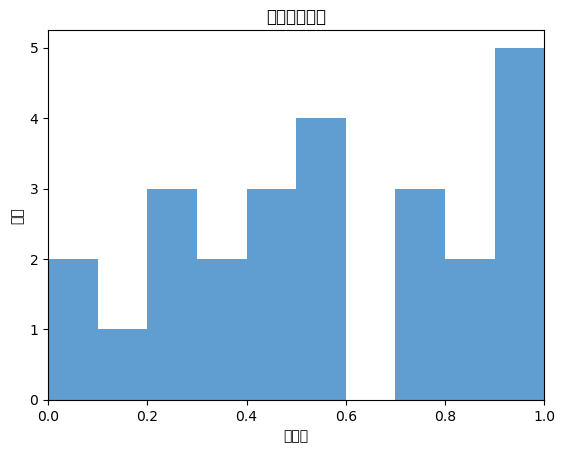

In [27]:
#情感分直方图
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False

bins=np.arange(0,1.1,0.1)
plt.hist(data1['emotion'],bins,color='#4F94CD',alpha=0.9)
plt.xlim(0,1)
plt.xlabel('情感分')
plt.ylabel('数量')
plt.title('情感分直方图')

plt.show()

#### 由直方图可见，高意愿评论和低意愿评论占比突出，中间区间的中性评论数量相对较少。
#### 有5条评论意愿度在 [0.9, 1.0] 区间，有2条评论意愿度在 [0.0, 0.1] 区间，整体态度偏积极。意愿度在 0.2~0.8 区间的评论数量分布较为均匀，说明仍有部分用户态度中性，购买意愿不够明确。

## 2.3 词云图

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/g1/w9fqp15913v6blnw_bqhxsdr0000gn/T/jieba.cache
Loading model cost 0.430 seconds.
Prefix dict has been built successfully.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not fo

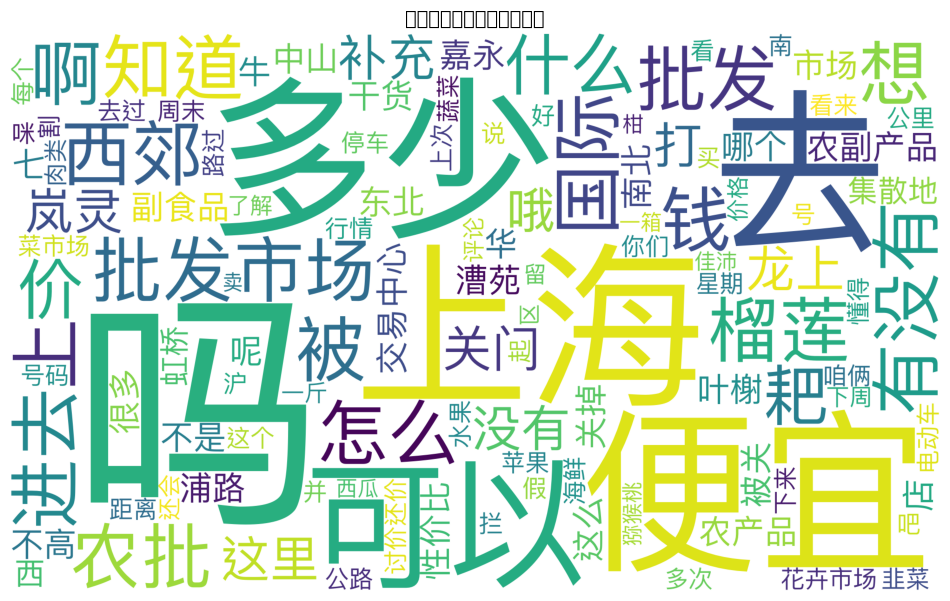

In [29]:
from wordcloud import WordCloud
import jieba
import matplotlib.pyplot as plt

text = ' '.join(data1['评论'].astype(str))
data_cut = ' '.join(jieba.lcut(text))
# 生成词云（适配Mac系统）
w = WordCloud(
    font_path="/System/Library/Fonts/PingFang.ttc",  # Mac自带中文字体，不用单独放字体
    stopwords=['的','我','了','是','和','都','就','在','也','很','这','不','有','你','吃','还'],
    width=2000,
    height=1200,
    background_color="white"
).generate(data_cut)

# 保存 + 显示
w.to_file('水果评论词云图.png')

plt.figure(figsize=(12,8))
plt.imshow(w)
plt.axis("off")
plt.title("用户水果评论关键词词云图", fontsize=14)
plt.show()

## 2.4 关键词提取

In [30]:
#关键词top10
from jieba import analyse 
key_words = jieba.analyse.extract_tags(sentence=text, topK=10, withWeight=True, allowPOS=())
key_words

[('农批', 0.23440720593921568),
 ('榴莲', 0.22226918224509806),
 ('便宜', 0.2046623807729412),
 ('批发市场', 0.17244572898196078),
 ('西郊', 0.17244572898196078),
 ('批发', 0.15792625248862743),
 ('多少', 0.15516784907029413),
 ('上海', 0.13481287239235296),
 ('有没有', 0.1332010230954902),
 ('进去', 0.12265254808921568)]

#### 以上关键词显示，消费者比较在意水果中的“榴莲”和“便宜”的商品特点

# 3 积极评论与消极评论

## 3.1 积极评论与消极评论占比

In [31]:
#计算积极评论与消极评论各自的数目
pos = 0
neg = 0
for i in data1['emotion']:
    if i >= 0.5:
        pos += 1
    else:
        neg += 1
print('积极评论，消极评论数目分别为：',pos,neg)

积极评论，消极评论数目分别为： 14 11


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

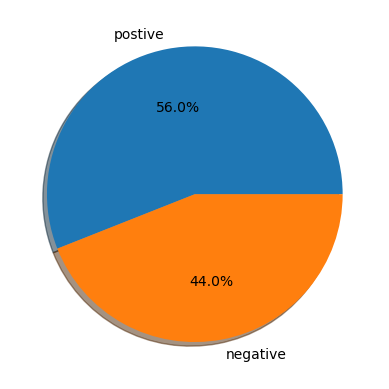

In [32]:
# 积极评论占比
import matplotlib.pyplot as plt 

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False

pie_labels='postive','negative'
plt.pie([pos,neg],labels=pie_labels,autopct='%1.1f%%',shadow=True)

plt.show()

## 3.2 消极评论分析

In [33]:
#获取消极评论数据
data2=data1[data1['emotion']<0.5]
data2.head(10)

,用户名,评论,emotion
0,上海周末去哪,有补充的可以打在这里哦,0.403604
5,小红薯69E91629,七浦路店还在吗，不是很多都关掉了吗,0.165631
10,唐景行远,看来我每个星期去的是假的上农批。,0.446053
12,芸花,沪南公路2000号上农批海鲜批发有吗？,0.207926
13,深爱不离 久爱不弃,有没有号码,0.259259
14,七妈育儿经,停车多少钱？,0.266717
21,小红薯60372687,去过多次，并不便宜。,0.496526
23,公园控,怎么进去啊？我上次起电动车路过想进去被拦下来了,0.031624
25,Zero,榴莲多少钱一斤,0.048749
26,嘻嘻嘻,下周还会去，想了解知道价格的，可以留评论区,0.314423


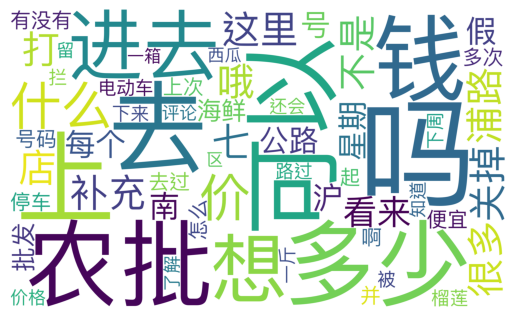

In [34]:
#消极评论词云图
text2 = ''
for s in data2['评论']:
    text2 += s
data_cut2 = ' '.join(jieba.lcut(text2))
w.generate(data_cut2)
image = w.to_file('消极评论词云.png')

# 显示词云文件
plt.imshow(w)
plt.axis("off")
plt.show()

In [35]:
#消极评论关键词top10
key_words = jieba.analyse.extract_tags(sentence=text2, topK=10, withWeight=True, allowPOS=())
key_words

[('农批', 0.5433985228590908),
 ('进去', 0.2843309069340909),
 ('2000', 0.2716992614295454),
 ('浦路', 0.26359301270454544),
 ('榴莲', 0.25763018851136366),
 ('多少', 0.23980485765409093),
 ('一箱', 0.22443922639181818),
 ('关掉', 0.22364169639613635),
 ('海鲜', 0.22036329619499997),
 ('一斤', 0.19439932093772727)]

# 总结

#### 本文使用jieba，snownlp，wordcloud，matplotlib等模块对文本数据进行了简要的情感分析及可视化，旨在了解用户使用体验，以此对平台运营提出优化建议。